# How Facial Recognition Bias Compounds Across Race and Gender as Subjects Age
### CS109b Group #18
### Jenni Arakaki, Arian Mundi, Laine Roper
Proj Spreadsheet: https://docs.google.com/spreadsheets/d/1MIKKfEiG-V2uaRrw7wUS3cBJXj6Yq_7IYiDK9poPT3I/edit?gid=530752263#gid=530752263

Proj Proposal: https://drive.google.com/file/d/1yRPxpvg4jQc8gwzPgP_ptiSU6Qs4qmL1/view


### Downloading/Accessing data:
1) Download zipfile from https://www.kaggle.com/datasets/jangedoo/utkface-new.
2) Set up a data folder and upload to GPU
3) Change file paths as necessary and run below code

In [1]:
# Standard library
import os
import gc
import time
import warnings

# Numerical computing and data processing
import numpy as np
import pandas as pd
import random
from pathlib import Path
from collections import Counter
import zipfile


# Visualization
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from torchvision import datasets, models, transforms
from torchvision.models import ResNet50_Weights

# UMAP
#import umap
from tqdm import tqdm

In [2]:
# Suppress warnings
warnings.filterwarnings('ignore')

In [3]:
# change paths as needed
zip_path = "/shared/home/jea040/proj/data/archive.zip"
extract_to = "/shared/home/jea040/proj/data"
data_folder = "/shared/home/jea040/proj/data/UTKFace"

if os.path.isdir(data_folder):
    print("Folder exists")
else:
    print("Loading in Data")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

Folder exists


# PROBLEM: 
### Does the accuracy of CNN-based facial attribute prediction (age estimation and gender classification) degrade differently across racial and gender groups as subjects get older? 
### Specifically, investigate whether bias that appears modest or acceptable at younger age ranges becomes significantly more pronounced and more unequally distributed at older age ranges. A secondary question is whether the direction of errors (for example, systematically overestimating age, or misclassifying gender) differs by race, and whether these directional errors worsen with age.


## Datawrangling, EDA, visualizations

### Labels:

The labels of each face image is embedded in the file name, formated like [age]_[gender]_[race]_[date&time].jpg

- [age] is an integer from 0 to 116, indicating the age
- [gender] is either 0 (male) or 1 (female)
- [race] is an integer from 0 to 4, denoting White, Black, Asian, Indian, and Others (like Hispanic, Latino, Middle Eastern).
- [date&time] is in the format of yyyymmddHHMMSSFFF, showing the date and time an image was collected to UTKFace

Landmark localization (in the context of faces) means detecting key, predefined points on a face in an image.

These points are called landmarks and usually include things like:
- corners of the eyes
- tip of the nose
- edges of the mouth
- jawline points
- eyebrows

### Visualizing data:

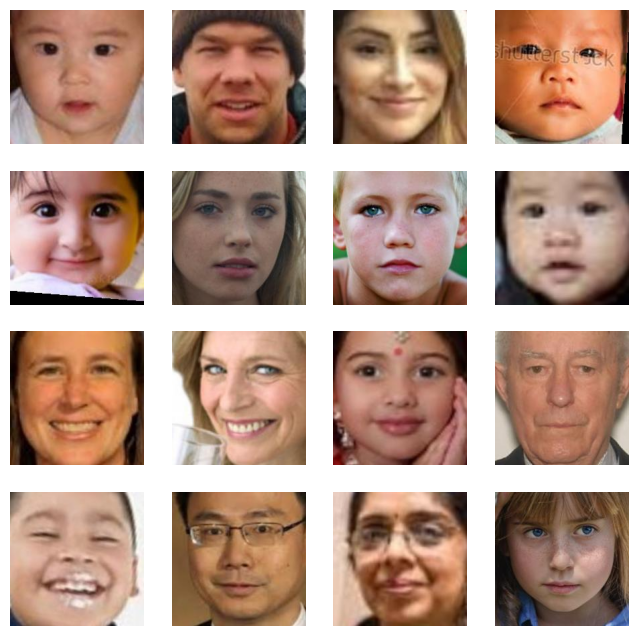

In [4]:
img_path = Path('/shared/home/jea040/proj/data/crop_part1')
image_list = []

for filename in img_path.glob('*.jpg'):
    im = Image.open(filename)
    image_list.append(im)

random.seed(1090)
rand = random.sample(image_list, 64)

fig, axes = plt.subplots(4, 4, figsize=(8,8))

for i, ax in enumerate(axes.flat):
    if i < len(rand):
        ax.imshow(rand[i])
        ax.axis('off')
    else:
        ax.axis('off')

In [5]:
# img_path = Path('/shared/home/jea040/proj/data/UTKFace')  
# age_counts = Counter()
# gender_counts = Counter()
# race_counts = Counter()

# for f in img_path.glob("*.jpg"):
#     # get filename without .jpg extension
#     stem = f.stem                           # "23_0_2_20170116174525125.jpg" -> "23_0_2_20170116174525125"
#     parts = stem.split("_")                # ["23", "0", "2", "20170116174525125"]

#     try:
#         age = int(parts[0])
#         gender = int(parts[1])
#         race = int(parts[2])
#     except (IndexError, ValueError):
#         # skip any unexpected filenames
#         continue

#     age_counts[age] += 1
#     gender_counts[gender] += 1
#     race_counts[race] += 1

# print("Age distribution (age: count):")
# print(dict(sorted(age_counts.items())))

# print("\nGender distribution (0=male, 1=female):")
# print(dict(sorted(gender_counts.items())))

# print("\nRace distribution (0=White, 1=Black, 2=Asian, 3=Indian, 4=Others):")
# print(dict(sorted(race_counts.items())))

# total = sum(age_counts.values())
# age_percent = {a: c / total * 100 for a, c in age_counts.items()}
# gender_percent = {g: c / total * 100 for g, c in gender_counts.items()}
# race_percent = {r: c / total * 100 for r, c in race_counts.items()}

# print('')
# print("Age %:", age_percent)
# print("Gender %:", gender_percent)
# print("Race %:", race_percent)

Age distribution (age: count):
{1: 1123, 2: 482, 3: 289, 4: 273, 5: 196, 6: 131, 7: 139, 8: 263, 9: 166, 10: 156, 11: 65, 12: 130, 13: 81, 14: 157, 15: 177, 16: 247, 17: 158, 18: 262, 19: 98, 20: 284, 21: 346, 22: 395, 23: 426, 24: 859, 25: 734, 26: 2197, 27: 615, 28: 918, 29: 570, 30: 724, 31: 350, 32: 664, 33: 143, 34: 409, 35: 880, 36: 483, 37: 293, 38: 325, 39: 265, 40: 526, 41: 132, 42: 266, 43: 157, 44: 100, 45: 440, 46: 153, 47: 170, 48: 153, 49: 148, 50: 381, 51: 138, 52: 232, 53: 241, 54: 353, 55: 268, 56: 236, 57: 97, 58: 271, 59: 82, 60: 293, 61: 159, 62: 125, 63: 103, 64: 50, 65: 259, 66: 77, 67: 94, 68: 100, 69: 56, 70: 147, 71: 33, 72: 98, 73: 63, 74: 32, 75: 148, 76: 58, 77: 28, 78: 69, 79: 23, 80: 133, 81: 22, 82: 40, 83: 18, 84: 24, 85: 155, 86: 35, 87: 10, 88: 34, 89: 33, 90: 82, 91: 2, 92: 13, 93: 5, 95: 9, 96: 17, 99: 9, 100: 11, 101: 2, 103: 1, 105: 5, 110: 5, 111: 1, 115: 3, 116: 4}

Gender distribution (0=male, 1=female):
{0: 12391, 1: 11314}

Race distribution (

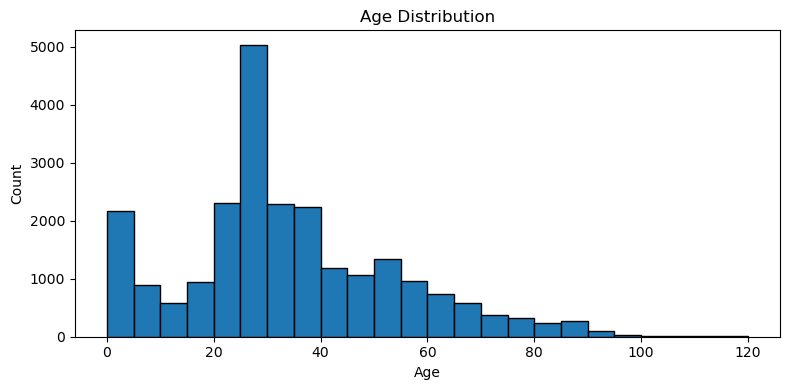

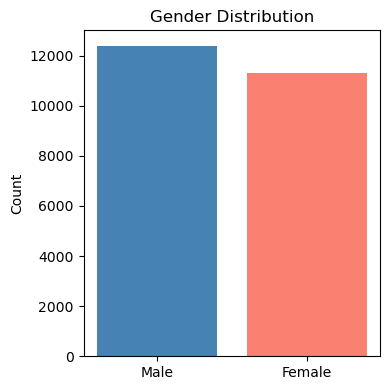

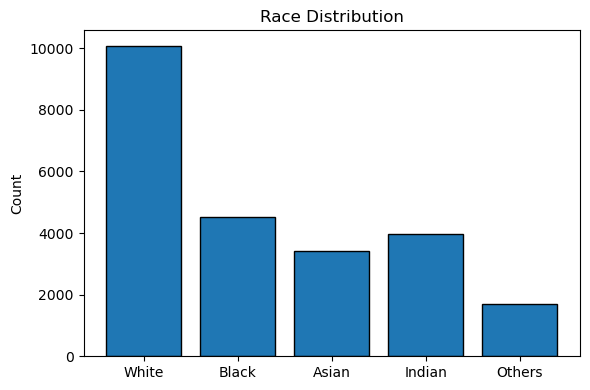

In [6]:
ages = []
genders = []
races = []

#Collect demographic details
for f in img_path.glob("*.jpg"):
    stem = f.stem          # filename without extension
    parts = stem.split("_")

    if len(parts) < 4:
        continue  # skip weird filenames

    try:
        age = int(parts[0])
        gender = int(parts[1])
        race = int(parts[2])
    except ValueError:
        print('Error with {f}')
        continue

    ages.append(age)
    genders.append(gender)
    races.append(race)

#Age distribution 
plt.figure(figsize=(8, 4))
plt.hist(ages, bins=range(0, 121, 5), edgecolor='black')  # 0-120 in steps of 5 years
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#Gender distribution 
gender_counts = Counter(genders)
gender_labels = ['Male', 'Female']
gender_values = [gender_counts.get(0, 0), gender_counts.get(1, 0)]

plt.figure(figsize=(4, 4))
plt.bar(gender_labels, gender_values, color=['steelblue', 'salmon'])
plt.title("Gender Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#Race distribution (bar plot)
race_counts = Counter(races)
race_labels_map = {
    0: "White",
    1: "Black",
    2: "Asian",
    3: "Indian",
    4: "Others"
}

race_labels = [race_labels_map[i] for i in range(5)]
race_values = [race_counts.get(i, 0) for i in range(5)]

plt.figure(figsize=(6, 4))
plt.bar(race_labels, race_values, edgecolor='black')
plt.title("Race Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Defining a dataframe with demographics

In [7]:
img_path = Path('/shared/home/jea040/proj/data/UTKFace')

rows = []

for f in img_path.glob("*.jpg"):
    parts = f.stem.split("_")
    
    try:
        age = int(parts[0])
        gender = int(parts[1])
        race = int(parts[2])
    except (IndexError, ValueError):
        continue
    
    rows.append({
        "filepath": str(f),
        "filename": f.name,
        "age": age,
        "gender": gender,
        "race": race
    })

df = pd.DataFrame(rows)

print(f"\nNumber of valid images: {len(df)}")

gender_map = {0: "male", 1: "female"}
race_map = {
    0: "White",
    1: "Black",
    2: "Asian",
    3: "Indian",
    4: "Others"
}

df["gender_label"] = df["gender"].map(gender_map)
df["race_label"] = df["race"].map(race_map)


Number of valid images: 23705


### Preliminary EDA

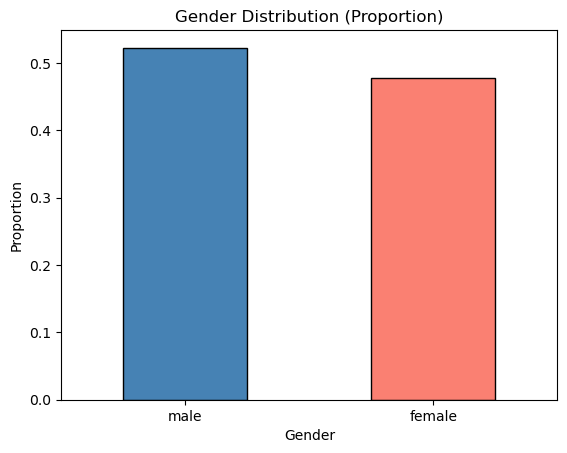

gender_label
male      0.522717
female    0.477283
Name: proportion, dtype: float64


<Axes: xlabel='gender_label', ylabel='age'>

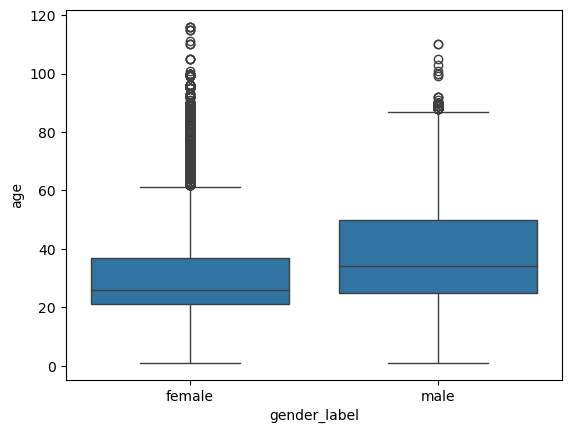

In [8]:
gender_dist = df["gender_label"].value_counts(normalize=True)

plt.figure()
gender_dist.plot(kind="bar", edgecolor='black', color=['steelblue', 'salmon'])
plt.title("Gender Distribution (Proportion)")
plt.xlabel("Gender")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

print(df["gender_label"].value_counts(normalize=True))

sns.boxplot(x="gender_label", y="age", data=df)

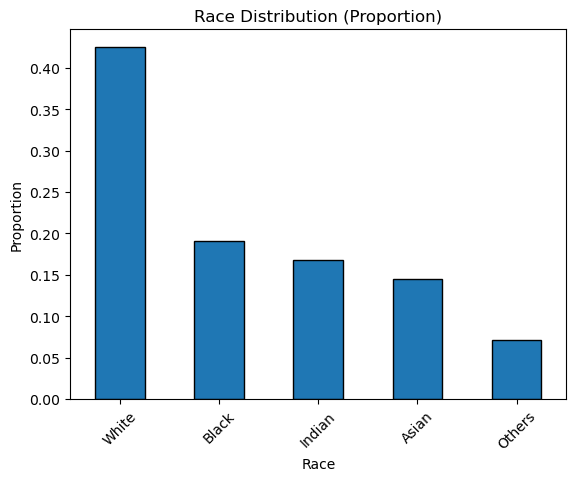

race_label
White     0.425142
Black     0.190930
Indian    0.167686
Asian     0.144864
Others    0.071377
Name: proportion, dtype: float64


In [9]:
race_dist = df["race_label"].value_counts(normalize=True)

plt.figure()
race_dist.plot(kind="bar", edgecolor='black')
plt.title("Race Distribution (Proportion)")
plt.xlabel("Race")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()

print(df["race_label"].value_counts(normalize=True))

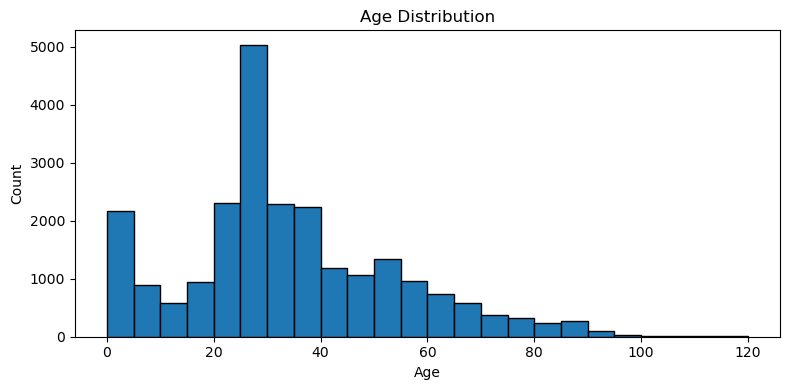

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(df["age"], bins=range(0, 121, 5), edgecolor='black')  # 0-120 in steps of 5 years
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [11]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 19, 35, 60, 120],
    labels=["child", "teen", "young_adult", "adult", "older_adult"],
    right=False
)

print(df["age_group"].value_counts())

age_group
young_adult    9732
adult          6790
child          3283
older_adult    2688
teen           1212
Name: count, dtype: int64


Text(0.5, 1.0, 'Age by Race')

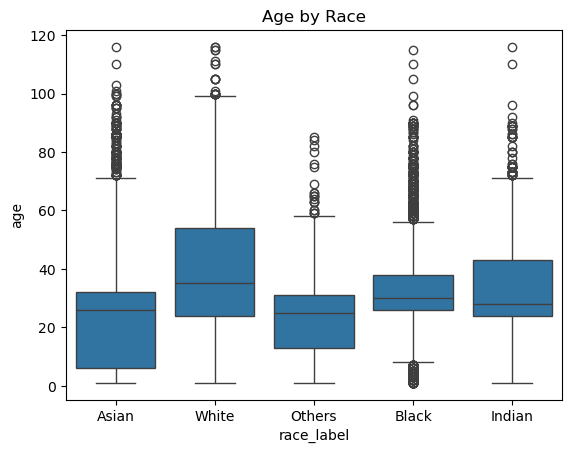

In [12]:
sns.boxplot(x="race_label", y="age", data=df)
plt.title("Age by Race")

Text(0.5, 1.0, 'Gender by Race')

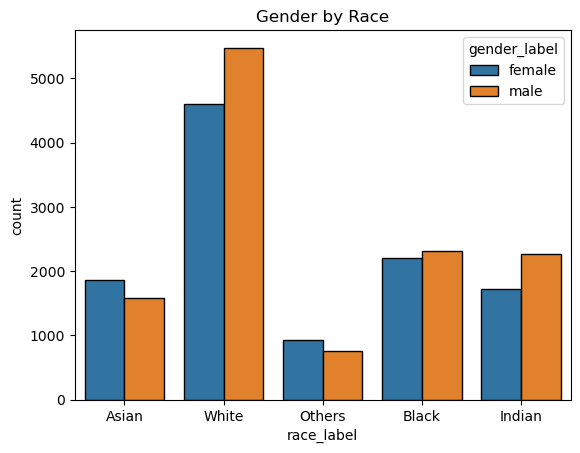

In [13]:
sns.countplot(x="race_label", hue="gender_label", data=df, edgecolor='black')
plt.title("Gender by Race")

### Key EDA Takeaways

#### 1. Gender distribution is relatively balanced
The dataset contains ~52% male and ~48% female samples

This indicates minimal gender imbalance overall

However, this balance does not guarantee fairness across subgroups (e.g., within each race or age group)

#### 2. Significant racial imbalance exists
White faces dominate (~42.5%)

Other groups are underrepresented:

- Black: ~19%
- Indian: ~16.8%
- Asian: ~14.5%
- Others: ~7.1%

#### 3. Age distribution is skewed (non-uniform)
Strong concentration in young adults (20–35)

Noticeable spike in very young ages (children/babies)

Teens are underrepresented

Gradual decline in samples for older ages

#### 4. Age distribution differs across gender
Males have a higher median age than females

Male age distribution is shifted older overall

Females are more concentrated in younger ranges

#### 5. Age distribution differs across race (important)
White group appears to have:

- higher median age
- wider spread

Other groups (e.g., Asian, Others) skew younger
Some races have fewer older individuals

#### 6. Gender imbalance varies across races
Some races (e.g., Indian) have more males than females

Others are more balanced

“Others” category is small and uneven

## Initial ResNet Training

### Train val test split

Stratifying the split to allow for subgroup fairness (addressing the issues seen in EDA).

Because some fine-grained age × race × gender subgroups contained too few samples for reliable stratified splitting, we stratified by race and gender only, while reserving age bins for downstream fairness evaluation.

Ages are binned to specifically look at the effect of fewer images of teens.

In [59]:
from sklearn.model_selection import train_test_split

labels = ["0_5",      # infants / toddlers
          "5_13",     # children
          "13_20",    # teens
          "21_40",
          "41_60",
          "61_80",
          "80_plus"
]

df["eval_age_bin"] = pd.cut(
    df["age"],
    bins = [0, 5, 13, 20, 40, 60, 80, 120],
    labels = labels,
    include_lowest=True
)

# simple stratification key
df["stratify_key"] = (
    df["race_label"].astype(str) + "_" +
    df["gender_label"].astype(str) + "_"
)

# remove very tiny groups if stratification breaks
valid_keys = df["stratify_key"].value_counts()
valid_keys = valid_keys[valid_keys >= 2].index
df_split = df[df["stratify_key"].isin(valid_keys)].copy()

train_df, temp_df = train_test_split(
    df_split,
    test_size=0.30,
    random_state=42,
    stratify=df_split["stratify_key"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["stratify_key"]
)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 16593
Validation size: 3556
Test size: 3556


### First Pass ResNet CNN

In [70]:
class UTKFaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["filepath"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        age = torch.tensor(row["age"], dtype=torch.float32)
        gender = torch.tensor(row["gender"], dtype=torch.float32)

        # keep subgroup info for later fairness analysis
        race = row["race_label"]
        age_bin = row["eval_age_bin"]

        return image, age, gender, race, age_bin

In [71]:
from torchvision import transforms

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# dataloaders
train_dataset = UTKFaceDataset(train_df, transform=train_transform)
val_dataset = UTKFaceDataset(val_df, transform=val_transform)
test_dataset = UTKFaceDataset(test_df, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)


class MultiTaskResNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.age_head = nn.Linear(in_features, 1)
        self.gender_head = nn.Linear(in_features, 1)

    def forward(self, x):
        features = self.backbone(x)

        age_pred = self.age_head(features).squeeze(1)         # shape: [batch]
        gender_logit = self.gender_head(features).squeeze(1)  # shape: [batch]

        return age_pred, gender_logit

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet_model = MultiTaskResNet().to(device)

age_criterion = nn.L1Loss()  # MAE-like loss for age
gender_criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(resnet_model.parameters(), lr=1e-4)

def train_one_epoch(model, loader, optimizer, age_criterion, gender_criterion, device):
    model.train()

    total_loss = 0.0
    total_age_loss = 0.0
    total_gender_loss = 0.0

    for images, ages, genders, _, _ in loader:
        images = images.to(device)
        ages = ages.to(device)
        genders = genders.to(device)

        optimizer.zero_grad()

        age_pred, gender_logit = model(images)

        age_loss = age_criterion(age_pred, ages)
        gender_loss = gender_criterion(gender_logit, genders)

        loss = age_loss + gender_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_age_loss += age_loss.item() * images.size(0)
        total_gender_loss += gender_loss.item() * images.size(0)

    n = len(loader.dataset)

    return {
        "loss": total_loss / n,
        "age_loss": total_age_loss / n,
        "gender_loss": total_gender_loss / n
    }

def evaluate(model, loader, age_criterion, gender_criterion, device):
    model.eval()

    total_loss = 0.0
    total_age_loss = 0.0
    total_gender_loss = 0.0

    all_age_preds = []
    all_ages = []
    all_gender_probs = []
    all_genders = []

    with torch.no_grad():
        for images, ages, genders, _, _ in loader:
            images = images.to(device)
            ages = ages.to(device)
            genders = genders.to(device)

            age_pred, gender_logit = model(images)

            age_loss = age_criterion(age_pred, ages)
            gender_loss = gender_criterion(gender_logit, genders)
            loss = age_loss + gender_loss

            total_loss += loss.item() * images.size(0)
            total_age_loss += age_loss.item() * images.size(0)
            total_gender_loss += gender_loss.item() * images.size(0)

            gender_probs = torch.sigmoid(gender_logit)
            gender_preds = (gender_probs >= 0.5).float()

            all_age_preds.append(age_pred.cpu())
            all_ages.append(ages.cpu())
            all_gender_probs.append(gender_preds.cpu())
            all_genders.append(genders.cpu())

    all_age_preds = torch.cat(all_age_preds)
    all_ages = torch.cat(all_ages)
    all_gender_preds = torch.cat(all_gender_probs)
    all_genders = torch.cat(all_genders)

    # age mean absolute error for age prediction
    age_mae = torch.mean(torch.abs(all_age_preds - all_ages)).item()
    gender_acc = (all_gender_preds == all_genders).float().mean().item()

    n = len(loader.dataset)

    return {
        "loss": total_loss / n,
        "age_loss": total_age_loss / n,
        "gender_loss": total_gender_loss / n,
        "age_mae": age_mae,
        "gender_acc": gender_acc
    }

In [72]:
num_epochs = 10

history = {
    "train_loss": [],
    "val_loss": [],
    "val_age_mae": [],
    "val_gender_acc": []
}

best_val_mae = float("inf")

start_time = time.time()

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        resnet_model, train_loader, optimizer,
        age_criterion, gender_criterion, device
    )

    val_metrics = evaluate(
        resnet_model, val_loader,
        age_criterion, gender_criterion, device
    )

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_age_mae"].append(val_metrics["age_mae"])
    history["val_gender_acc"].append(val_metrics["gender_acc"])

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_metrics['loss']:.4f} | "
          f"Val Loss: {val_metrics['loss']:.4f} | "
          f"Age MAE: {val_metrics['age_mae']:.2f} | "
          f"Gender Acc: {val_metrics['gender_acc']:.3f}")

    if (val_metrics["age_mae"] < best_val_mae or
        (abs(val_metrics["age_mae"] - best_val_mae) < 1e-4 and
        val_metrics["gender_acc"] > best_gender_acc)):
    
        best_val_mae = val_metrics["age_mae"]
        best_gender_acc = val_metrics["gender_acc"]
        torch.save(resnet_model.state_dict(), "best_resnet.pt")
        print("  → Saved new best model")

end_time = time.time()

total_time = end_time - start_time
print(f"\nTotal training time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")

Epoch 01 | Train Loss: 24.1554 | Val Loss: 17.5627 | Age MAE: 17.29 | Gender Acc: 0.894
  → Saved new best model
Epoch 02 | Train Loss: 10.9379 | Val Loss: 7.2240 | Age MAE: 6.99 | Gender Acc: 0.901
  → Saved new best model
Epoch 03 | Train Loss: 6.2325 | Val Loss: 6.4392 | Age MAE: 6.25 | Gender Acc: 0.925
  → Saved new best model
Epoch 04 | Train Loss: 5.3928 | Val Loss: 5.4841 | Age MAE: 5.29 | Gender Acc: 0.922
  → Saved new best model
Epoch 05 | Train Loss: 5.0584 | Val Loss: 5.1840 | Age MAE: 5.00 | Gender Acc: 0.925
  → Saved new best model
Epoch 06 | Train Loss: 4.7828 | Val Loss: 5.3520 | Age MAE: 5.15 | Gender Acc: 0.913
Epoch 07 | Train Loss: 4.5175 | Val Loss: 5.2567 | Age MAE: 5.06 | Gender Acc: 0.923
Epoch 08 | Train Loss: 4.4114 | Val Loss: 5.1540 | Age MAE: 4.97 | Gender Acc: 0.929
  → Saved new best model
Epoch 09 | Train Loss: 4.2528 | Val Loss: 5.1871 | Age MAE: 5.01 | Gender Acc: 0.933
Epoch 10 | Train Loss: 3.9611 | Val Loss: 5.0174 | Age MAE: 4.83 | Gender Acc: 0.

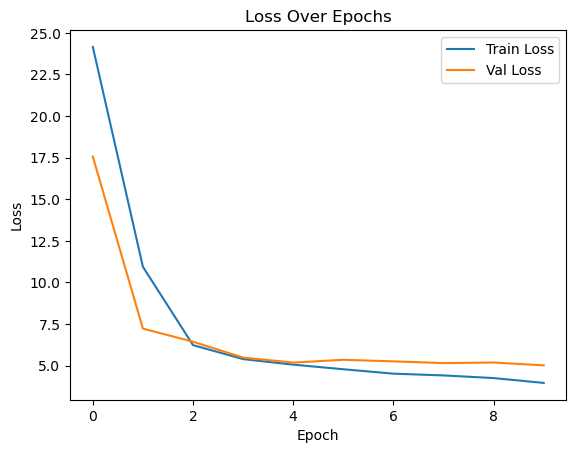

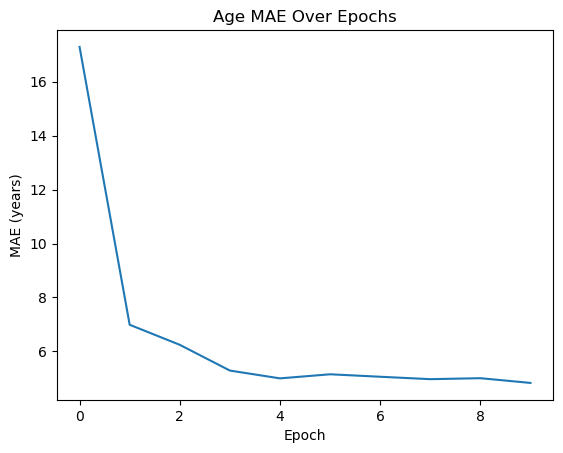

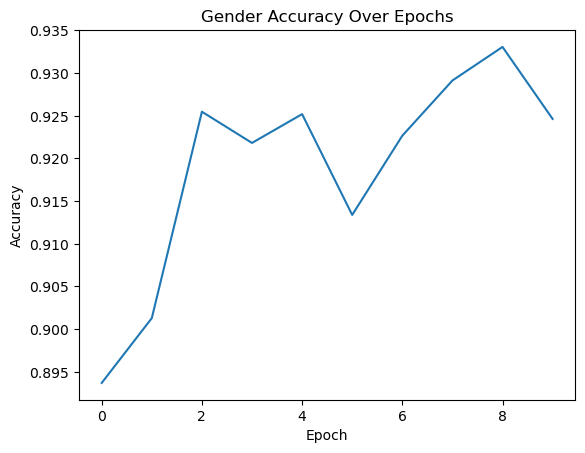

In [73]:
plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(history["val_age_mae"], label="Val Age MAE")
plt.title("Age MAE Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MAE (years)")
plt.show()

plt.figure()
plt.plot(history["val_gender_acc"], label="Val Gender Acc")
plt.title("Gender Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

We observe an elbow in loss at epoch 2 (quite early). Age MAE plateaus around 2, also relatively soon in the training. However, gender continues to improve as we train more epochs.

In [74]:
def get_test_predictions(model, loader, device):
    model.eval()

    results = []

    with torch.no_grad():
        for images, ages, genders, races, age_bins in loader:
            images = images.to(device)

            age_pred, gender_logit = model(images)
            gender_prob = torch.sigmoid(gender_logit)
            gender_pred = (gender_prob >= 0.5).float()

            for i in range(len(images)):
                results.append({
                    "true_age": ages[i].item(),
                    "pred_age": age_pred[i].item(),
                    "age_error": age_pred[i].item() - ages[i].item(),
                    "true_gender": int(genders[i].item()),
                    "pred_gender": int(gender_pred[i].item()),
                    "gender_correct": int(gender_pred[i].item() == genders[i].item()),
                    "race_label": races[i],
                    "eval_age_bin": str(age_bins[i])
                })

    return pd.DataFrame(results)

In [75]:
test_results = get_test_predictions(resnet_model, test_loader, device)

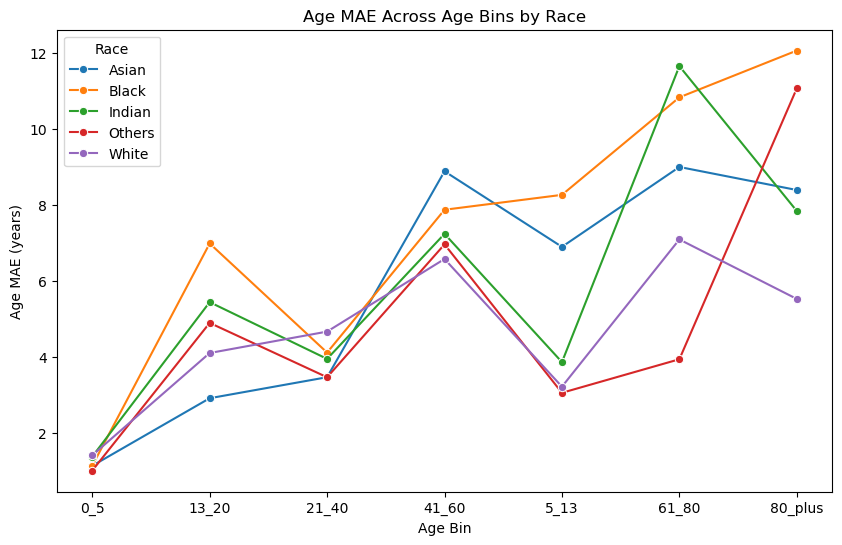

In [76]:
age_mae_by_group = (
    test_results
    .groupby(["eval_age_bin", "race_label"])["age_error"]
    .apply(lambda x: x.abs().mean())
    .reset_index(name="age_mae")
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=age_mae_by_group,
    x="eval_age_bin",
    y="age_mae",
    hue="race_label",
    marker="o"
)
plt.title("Age MAE Across Age Bins by Race")
plt.xlabel("Age Bin")
plt.ylabel("Age MAE (years)")
plt.legend(title="Race")
plt.show()

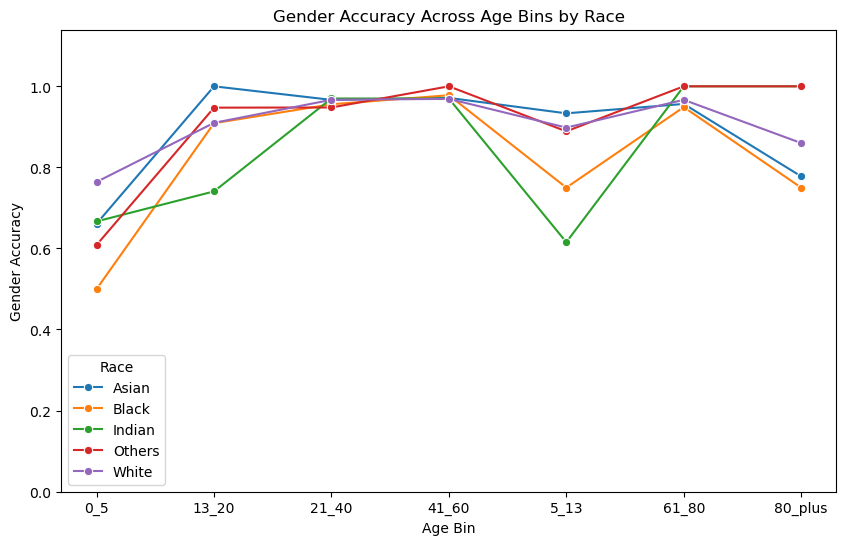

In [77]:
gender_acc_by_group = (
    test_results
    .groupby(["eval_age_bin", "race_label"])["gender_correct"]
    .mean()
    .reset_index(name="gender_accuracy")
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=gender_acc_by_group,
    x="eval_age_bin",
    y="gender_accuracy",
    hue="race_label",
    marker="o"
)
plt.title("Gender Accuracy Across Age Bins by Race")
plt.xlabel("Age Bin")
plt.ylabel("Gender Accuracy")
plt.ylim(0, 1.14)
plt.legend(title="Race")
plt.show()

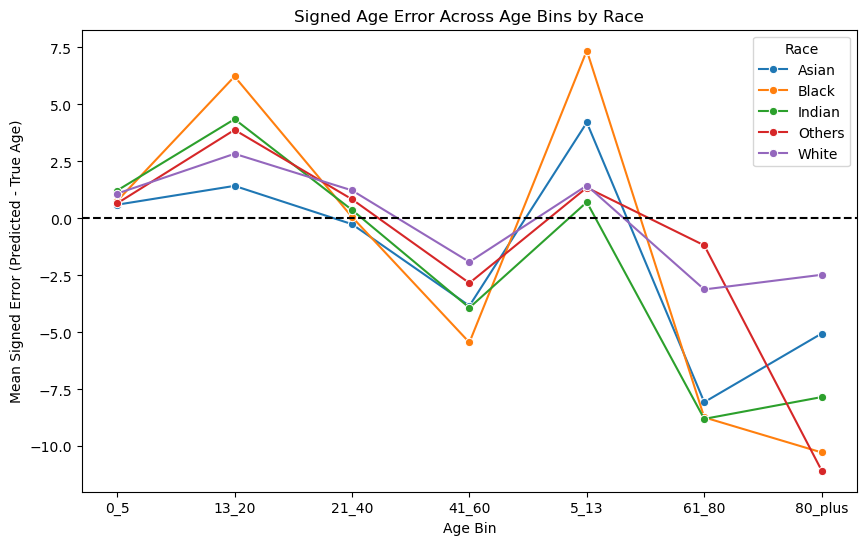

In [78]:
signed_error_by_group = (
    test_results
    .groupby(["eval_age_bin", "race_label"])["age_error"]
    .mean()
    .reset_index(name="mean_signed_error")
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=signed_error_by_group,
    x="eval_age_bin",
    y="mean_signed_error",
    hue="race_label",
    marker="o"
)

plt.axhline(0, linestyle="--", color="black")
plt.title("Signed Age Error Across Age Bins by Race")
plt.xlabel("Age Bin")
plt.ylabel("Mean Signed Error (Predicted - True Age)")
plt.legend(title="Race")

plt.show()

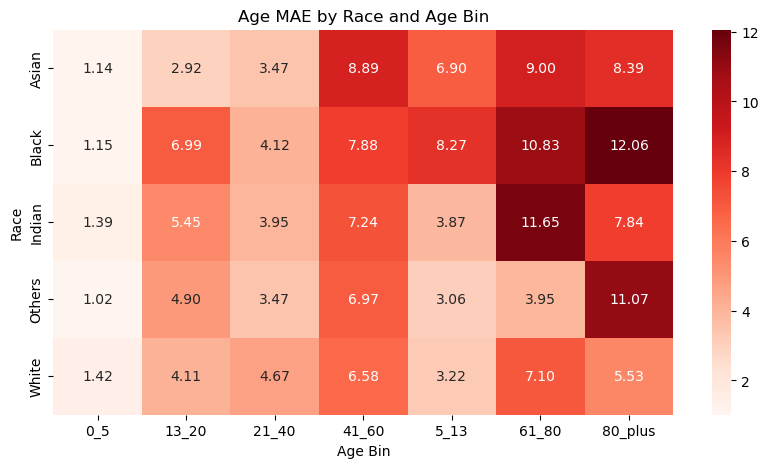

In [79]:
age_mae_pivot = age_mae_by_group.pivot(
    index="race_label",
    columns="eval_age_bin",
    values="age_mae"
)

plt.figure(figsize=(10, 5))
sns.heatmap(age_mae_pivot, annot=True, fmt=".2f", cmap="Reds")
plt.title("Age MAE by Race and Age Bin")
plt.xlabel("Age Bin")
plt.ylabel("Race")
plt.show()

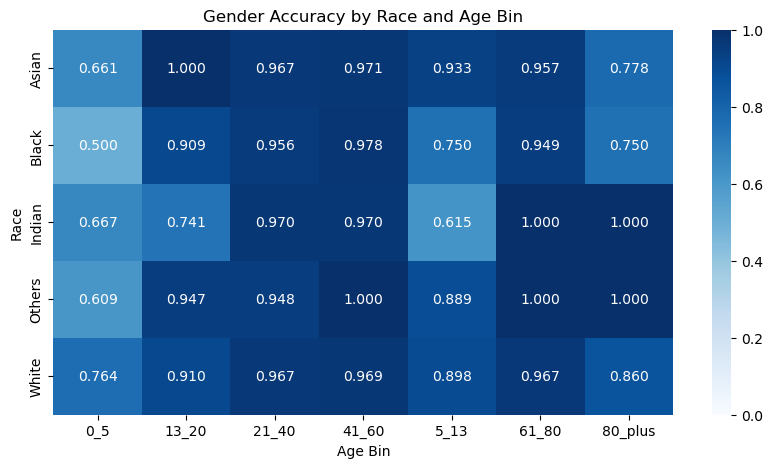

In [80]:
gender_acc_pivot = gender_acc_by_group.pivot(
    index="race_label",
    columns="eval_age_bin",
    values="gender_accuracy"
)

plt.figure(figsize=(10, 5))
sns.heatmap(gender_acc_pivot, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1)
plt.title("Gender Accuracy by Race and Age Bin")
plt.xlabel("Age Bin")
plt.ylabel("Race")
plt.show()

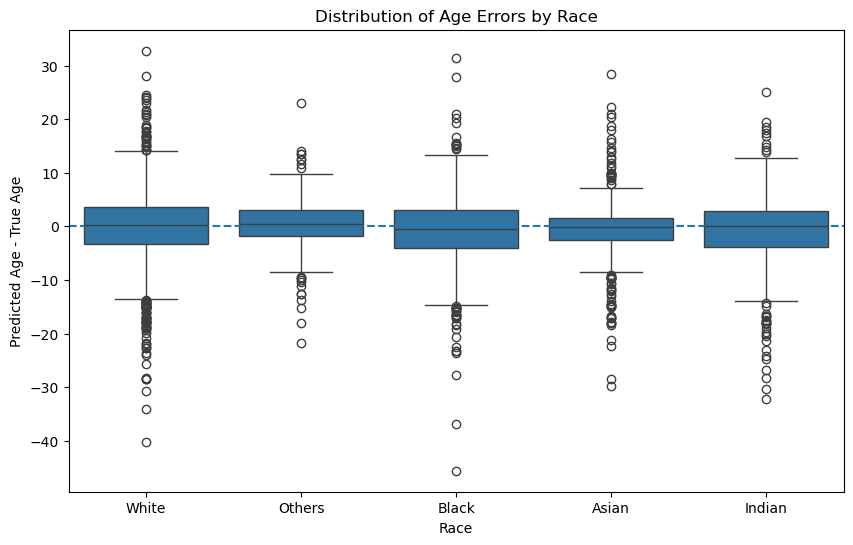

In [81]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=test_results, x="race_label", y="age_error")
plt.axhline(0, linestyle="--")
plt.title("Distribution of Age Errors by Race")
plt.xlabel("Race")
plt.ylabel("Predicted Age - True Age")
plt.show()

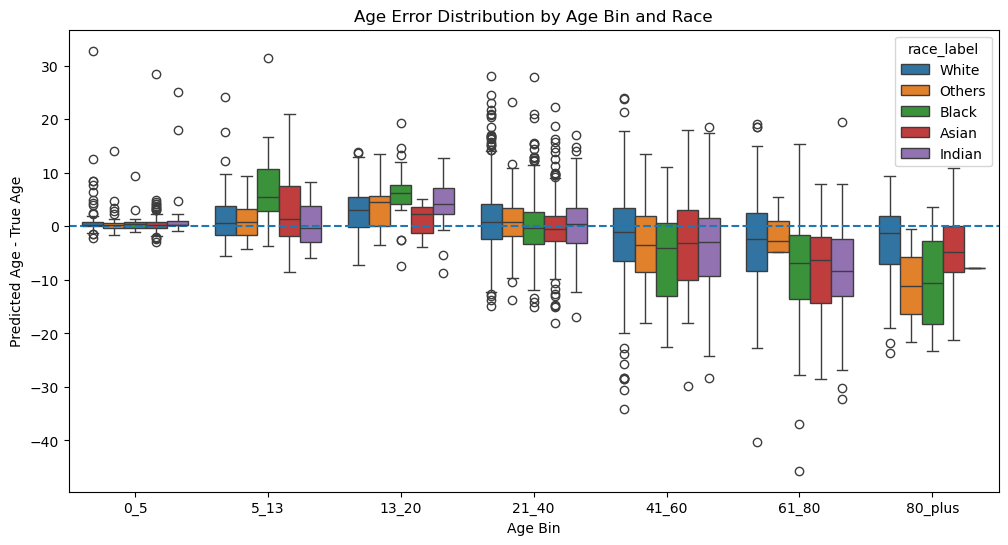

In [82]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=test_results, 
            x="eval_age_bin", 
            y="age_error", 
            hue="race_label", 
            order=labels)
plt.axhline(0, linestyle="--")
plt.title("Age Error Distribution by Age Bin and Race")
plt.xlabel("Age Bin")
plt.ylabel("Predicted Age - True Age")
plt.show()

- As age increases, MAE increases.
- Age MAE between races grows in a similar pattern with all of the major race groups and is much more sporadic for the "other" category.
- The model tends to predict younger for all categories above 20.

First Pass EfficientNet CNN

In [83]:
class MultiTaskEfficientNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )

        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        self.age_head = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

        self.gender_head = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        features = self.backbone(x)
        age_pred = self.age_head(features).squeeze(1)
        gender_logit = self.gender_head(features).squeeze(1)
        return age_pred, gender_logit

In [84]:
best_val_mae = float("inf")
best_gender_acc = 0

effnet_model = MultiTaskEfficientNet().to(device)
optimizer = torch.optim.Adam(effnet_model.parameters(), lr=1e-4)


num_epochs = 10

history = {
    "train_loss": [],
    "val_loss": [],
    "val_age_mae": [],
    "val_gender_acc": []
}

best_val_mae = float("inf")
best_gender_acc = 0

start_time = time.time()

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        effnet_model, train_loader, optimizer,
        age_criterion, gender_criterion, device
    )

    val_metrics = evaluate(
        effnet_model, val_loader,
        age_criterion, gender_criterion, device
    )

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_age_mae"].append(val_metrics["age_mae"])
    history["val_gender_acc"].append(val_metrics["gender_acc"])

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_metrics['loss']:.4f} | "
          f"Val Loss: {val_metrics['loss']:.4f} | "
          f"Age MAE: {val_metrics['age_mae']:.2f} | "
          f"Gender Acc: {val_metrics['gender_acc']:.3f}")

    if (
        val_metrics["age_mae"] < best_val_mae or
        (
            abs(val_metrics["age_mae"] - best_val_mae) < 1e-4 and
            val_metrics["gender_acc"] > best_gender_acc
        )
    ):
        best_val_mae = val_metrics["age_mae"]
        best_gender_acc = val_metrics["gender_acc"]
        torch.save(effnet_model.state_dict(), "best_efficientnet.pt")
        print("  → Saved new best model")

end_time = time.time()

total_time = end_time - start_time
print(f"\nTotal training time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")

Epoch 01 | Train Loss: 15.3910 | Val Loss: 7.1020 | Age MAE: 6.77 | Gender Acc: 0.853
  → Saved new best model
Epoch 02 | Train Loss: 7.3747 | Val Loss: 6.3521 | Age MAE: 6.08 | Gender Acc: 0.875
  → Saved new best model
Epoch 03 | Train Loss: 6.6709 | Val Loss: 6.0863 | Age MAE: 5.82 | Gender Acc: 0.879
  → Saved new best model
Epoch 04 | Train Loss: 6.1974 | Val Loss: 5.8672 | Age MAE: 5.62 | Gender Acc: 0.889
  → Saved new best model
Epoch 05 | Train Loss: 5.7748 | Val Loss: 5.6482 | Age MAE: 5.42 | Gender Acc: 0.897
  → Saved new best model
Epoch 06 | Train Loss: 5.5154 | Val Loss: 5.6000 | Age MAE: 5.37 | Gender Acc: 0.901
  → Saved new best model
Epoch 07 | Train Loss: 5.3174 | Val Loss: 5.9174 | Age MAE: 5.71 | Gender Acc: 0.908
Epoch 08 | Train Loss: 5.0965 | Val Loss: 5.3928 | Age MAE: 5.18 | Gender Acc: 0.905
  → Saved new best model
Epoch 09 | Train Loss: 4.9476 | Val Loss: 5.5712 | Age MAE: 5.37 | Gender Acc: 0.915
Epoch 10 | Train Loss: 4.7406 | Val Loss: 5.8542 | Age MAE:

Compare against ResNet.

In [85]:
resnet_test_results = get_test_predictions(resnet_model, test_loader, device)
effnet_test_results = get_test_predictions(effnet_model, test_loader, device)

resnet_test_results["model"] = "ResNet18"
effnet_test_results["model"] = "EfficientNet-B0"

all_results = pd.concat(
    [resnet_test_results, effnet_test_results],
    ignore_index=True
)

age_order = ["0_5", "5_13", "13_20", "21_40", "41_60", "61_80", "80_plus"]

all_results["eval_age_bin"] = pd.Categorical(
    all_results["eval_age_bin"],
    categories=age_order,
    ordered=True
)

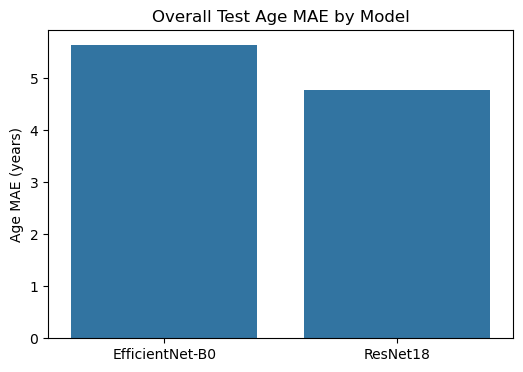

In [86]:
overall_age = (
    all_results.groupby("model")["age_error"]
    .apply(lambda x: x.abs().mean())
    .reset_index(name="age_mae")
)

plt.figure(figsize=(6, 4))
sns.barplot(data=overall_age, x="model", y="age_mae")
plt.title("Overall Test Age MAE by Model")
plt.ylabel("Age MAE (years)")
plt.xlabel("")
plt.show()

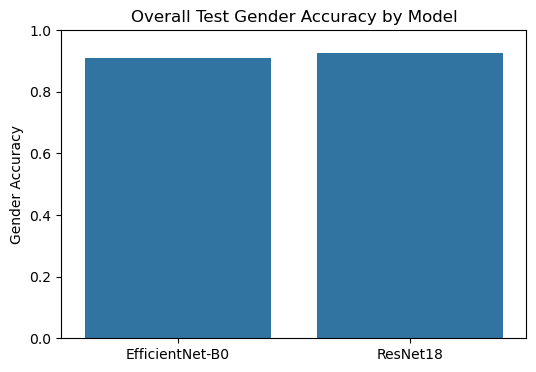

In [87]:
overall_gender = (
    all_results.groupby("model")["gender_correct"]
    .mean()
    .reset_index(name="gender_acc")
)

plt.figure(figsize=(6, 4))
sns.barplot(data=overall_gender, x="model", y="gender_acc")
plt.title("Overall Test Gender Accuracy by Model")
plt.ylabel("Gender Accuracy")
plt.xlabel("")
plt.ylim(0, 1)
plt.show()

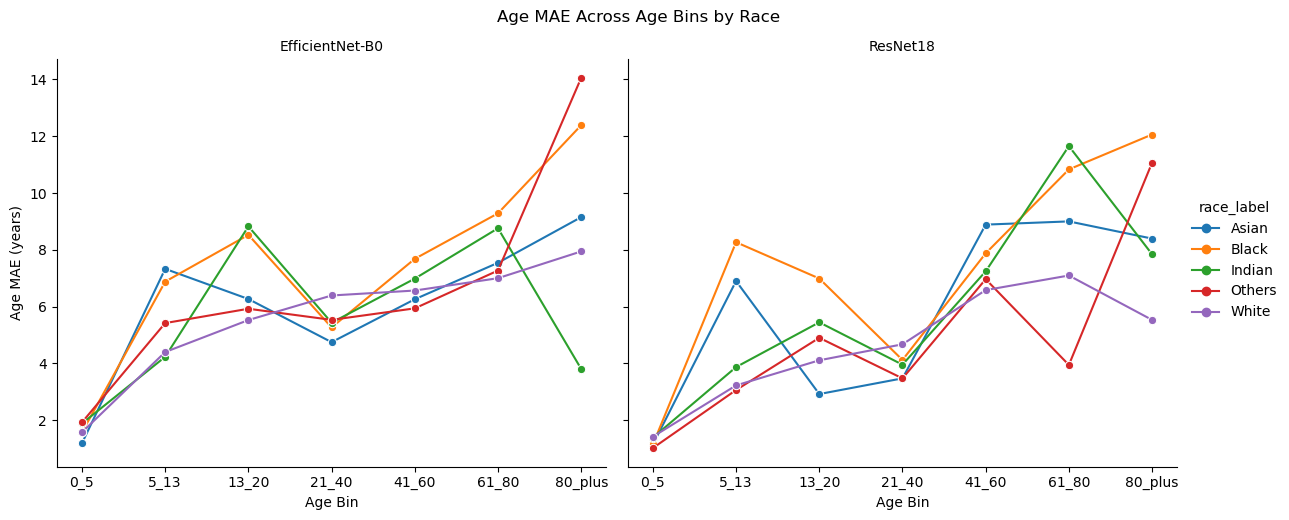

In [88]:
age_mae_plot = (
    all_results.groupby(["model", "eval_age_bin", "race_label"])["age_error"]
    .apply(lambda x: x.abs().mean())
    .reset_index(name="age_mae")
)

g = sns.relplot(
    data=age_mae_plot,
    x="eval_age_bin",
    y="age_mae",
    hue="race_label",
    col="model",
    kind="line",
    marker="o",
    height=5,
    aspect=1.2
)

g.set_axis_labels("Age Bin", "Age MAE (years)")
g.set_titles("{col_name}")
g.fig.suptitle("Age MAE Across Age Bins by Race", y=1.03)
plt.show()

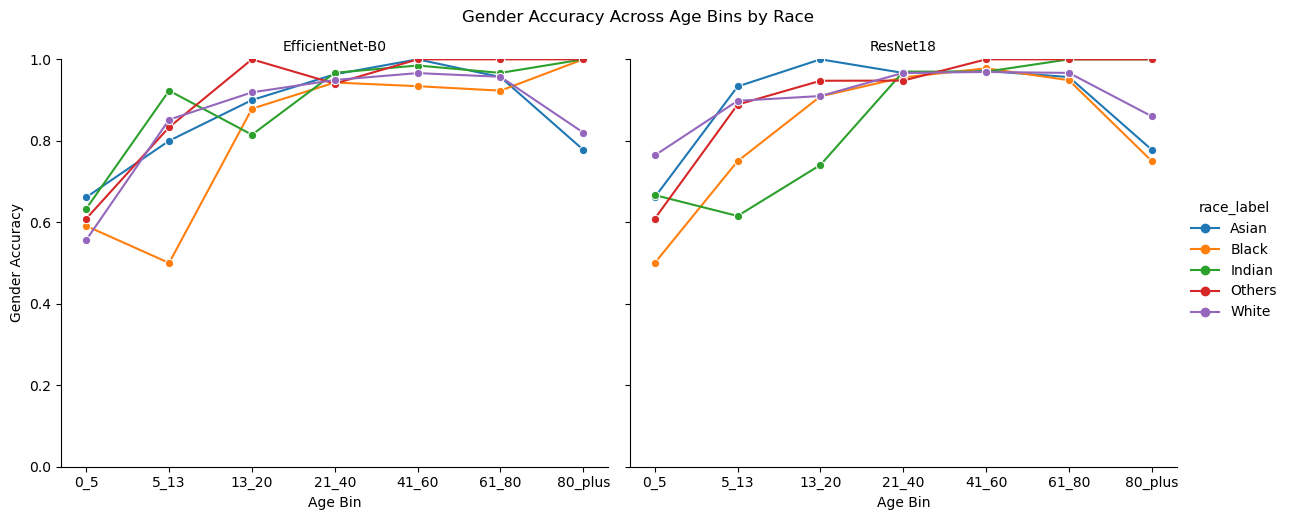

In [89]:
gender_acc_plot = (
    all_results.groupby(["model", "eval_age_bin", "race_label"])["gender_correct"]
    .mean()
    .reset_index(name="gender_acc")
)

g = sns.relplot(
    data=gender_acc_plot,
    x="eval_age_bin",
    y="gender_acc",
    hue="race_label",
    col="model",
    kind="line",
    marker="o",
    height=5,
    aspect=1.2
)

g.set_axis_labels("Age Bin", "Gender Accuracy")
g.set_titles("{col_name}")
g.set(ylim=(0, 1))
g.fig.suptitle("Gender Accuracy Across Age Bins by Race", y=1.03)
plt.show()

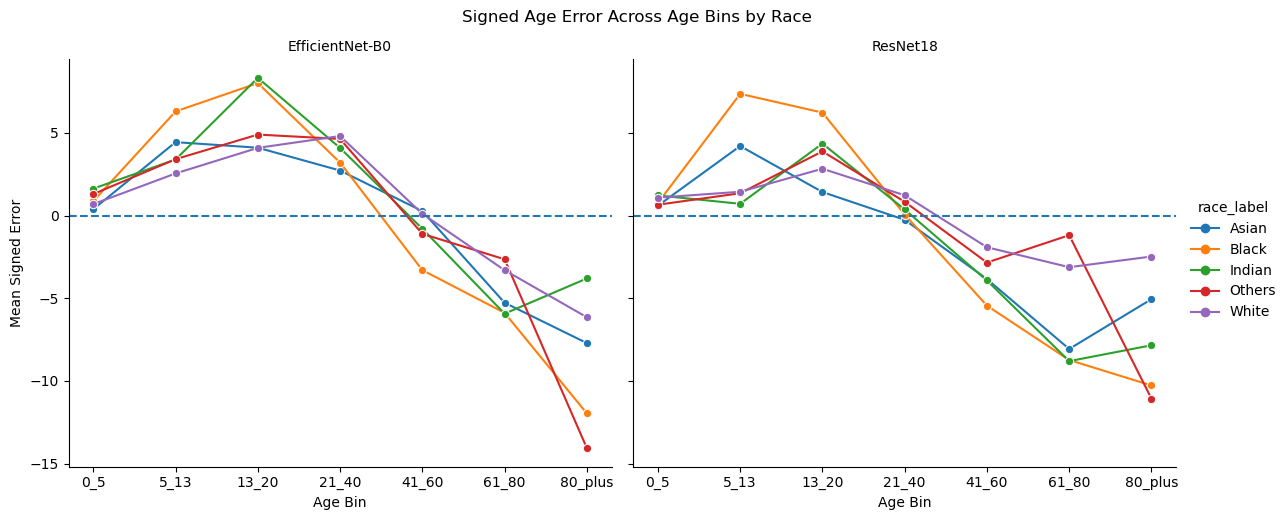

In [90]:
signed_error_plot = (
    all_results.groupby(["model", "eval_age_bin", "race_label"])["age_error"]
    .mean()
    .reset_index(name="signed_error")
)

g = sns.relplot(
    data=signed_error_plot,
    x="eval_age_bin",
    y="signed_error",
    hue="race_label",
    col="model",
    kind="line",
    marker="o",
    height=5,
    aspect=1.2
)

for ax in g.axes.flat:
    ax.axhline(0, linestyle="--")

g.set_axis_labels("Age Bin", "Mean Signed Error")
g.set_titles("{col_name}")
g.fig.suptitle("Signed Age Error Across Age Bins by Race", y=1.03)
plt.show()

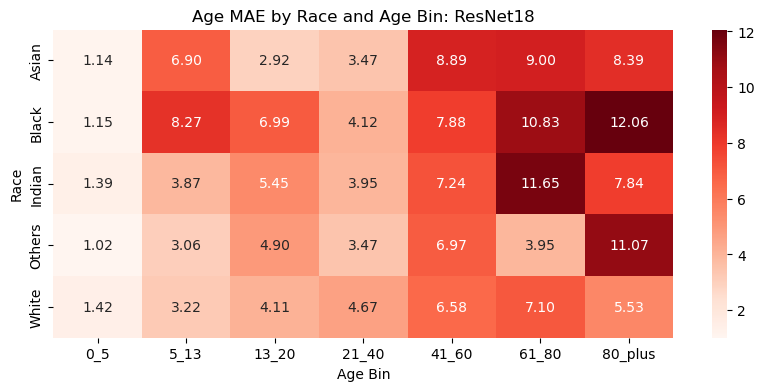

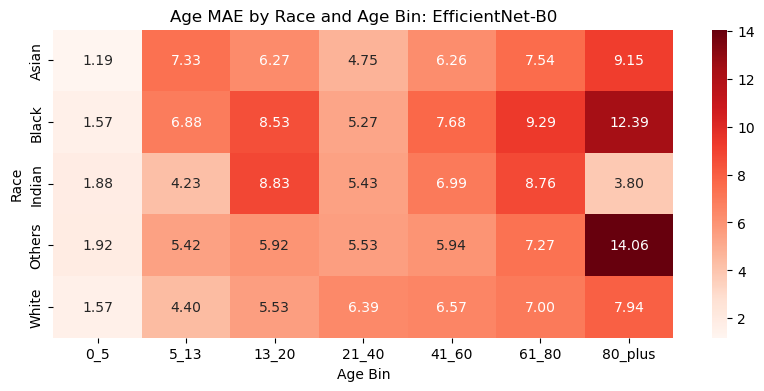

In [91]:
for model_name in all_results["model"].unique():
    temp = all_results[all_results["model"] == model_name]

    heat = (
        temp.groupby(["race_label", "eval_age_bin"])["age_error"]
        .apply(lambda x: x.abs().mean())
        .reset_index(name="age_mae")
        .pivot(index="race_label", columns="eval_age_bin", values="age_mae")
    )

    plt.figure(figsize=(10, 4))
    sns.heatmap(heat, annot=True, fmt=".2f", cmap="Reds")
    plt.title(f"Age MAE by Race and Age Bin: {model_name}")
    plt.xlabel("Age Bin")
    plt.ylabel("Race")
    plt.show()

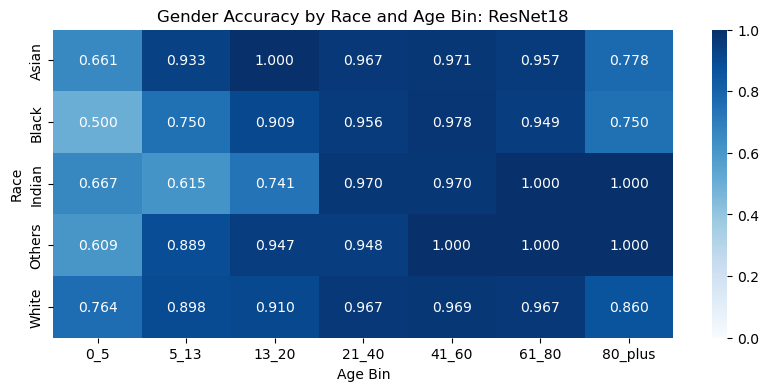

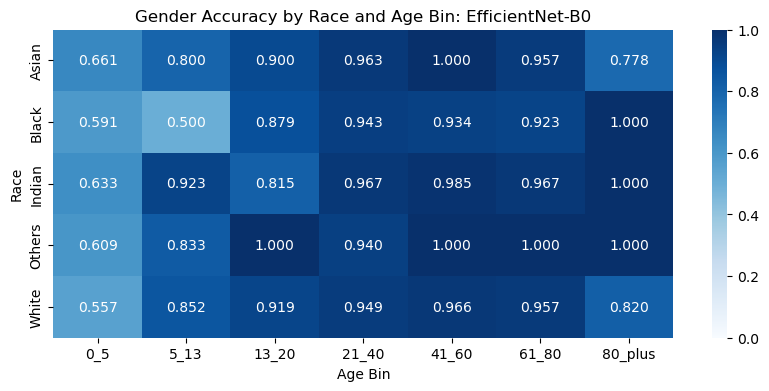

In [92]:
for model_name in all_results["model"].unique():
    temp = all_results[all_results["model"] == model_name]

    heat = (
        temp.groupby(["race_label", "eval_age_bin"])["gender_correct"]
        .mean()
        .reset_index(name="gender_acc")
        .pivot(index="race_label", columns="eval_age_bin", values="gender_acc")
    )

    plt.figure(figsize=(10, 4))
    sns.heatmap(heat, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1)
    plt.title(f"Gender Accuracy by Race and Age Bin: {model_name}")
    plt.xlabel("Age Bin")
    plt.ylabel("Race")
    plt.show()